In [1]:
import HeST as H
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import re

from qetpy.utils import fft, ifft, fftfreq, rfftfreq

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
plt.rcParams['figure.dpi'] = 200

## Making a Valid Simulation

We're just going to import a pre-defined detector geometry.

We're also going to briefly plot the detector volume; feel free to comment this line out if you feel it takes to long/you aren't interested in it

(<Figure size 1280x960 with 1 Axes>, <Axes3D: >)

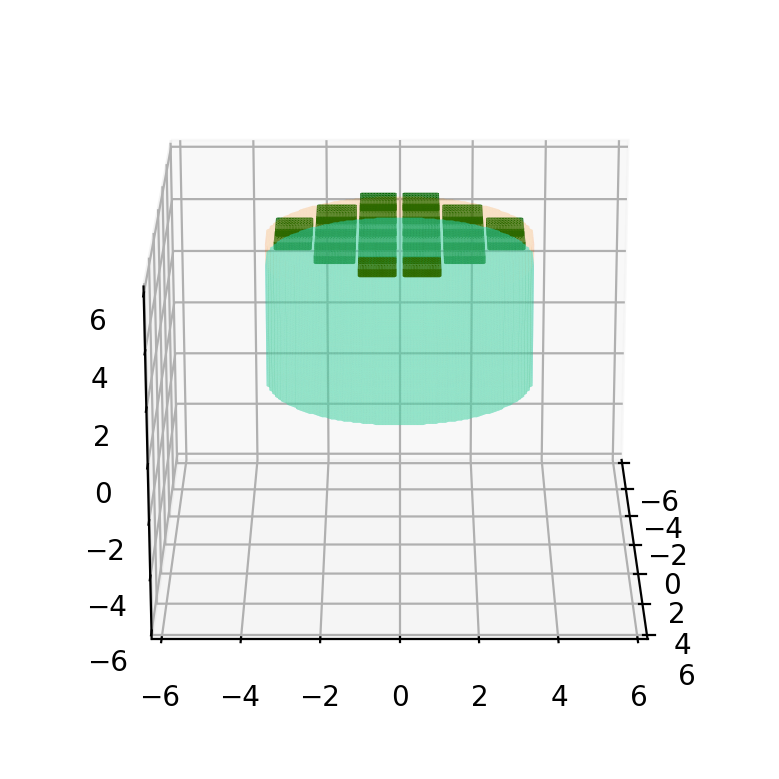

In [2]:
HeRALD_v1 = H.HeRALD_v1(fill_height=4.5)

HeRALD_v1.Plot_detector(xgrid = np.linspace(-4,4,100),
                        ygrid = np.linspace(-4,4,100),
                        zgrid = np.linspace(-1,5.5,100))

## Simple Singlet Simulation

Simple Simulation. 1 scintillation photon is generated and impinges on the vacuum interface with a fixed angle of incidence. 

Note that a Hest_Signal object is returned; this includes only energy deposits and timing information.

Crossing Helium/vapor interface
Reached an inert solid boundary


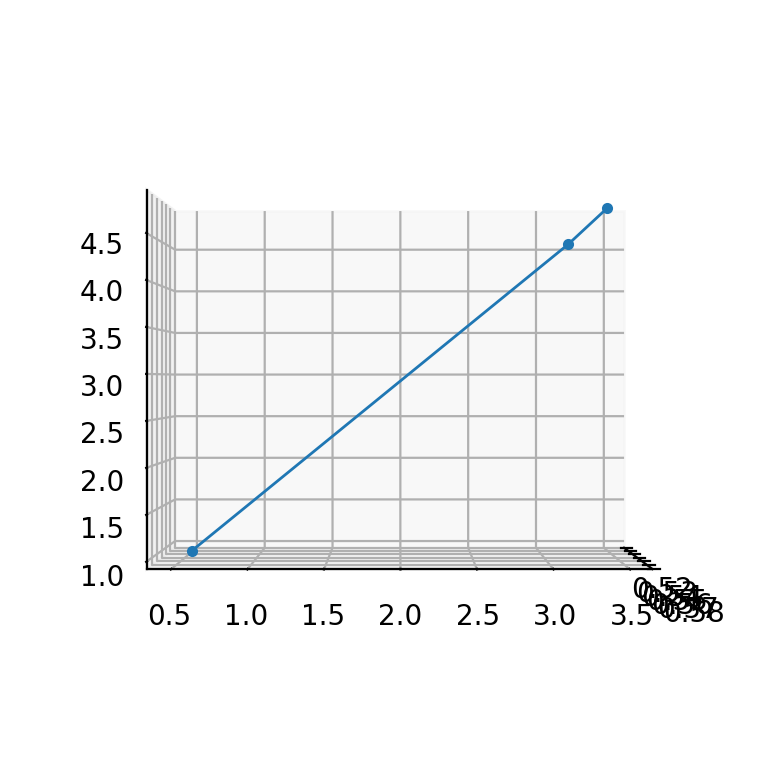

In [11]:
theta = 37#degrees


sensor_signal = H.GetSingletSignal(HeRALD_v1,1,
                                   .55, .55, 1,
                                   useMap=False,
                                   plot_3d = True,
                                   fixed_dir = (0, np.sin(theta * np.pi/180),np.cos(theta * np.pi/180)),
                                   debug = False,
                                   verbose = True
                                   )



## More Complex Singlet Signal

More complex (and realistic) simulation. We neglect to specify a fixed direction/momentum, so the photons are emitted isotropically. Since we're adding random chance, it makes sense to simulate more than one.

We also specify the debug flag which will return more detailed information that we would not be privy to in a realistic situation.

We also run a the same code with a lot more data points. (Frankly more than we would ever expect to see in a single event, but this reduces uncertainties)

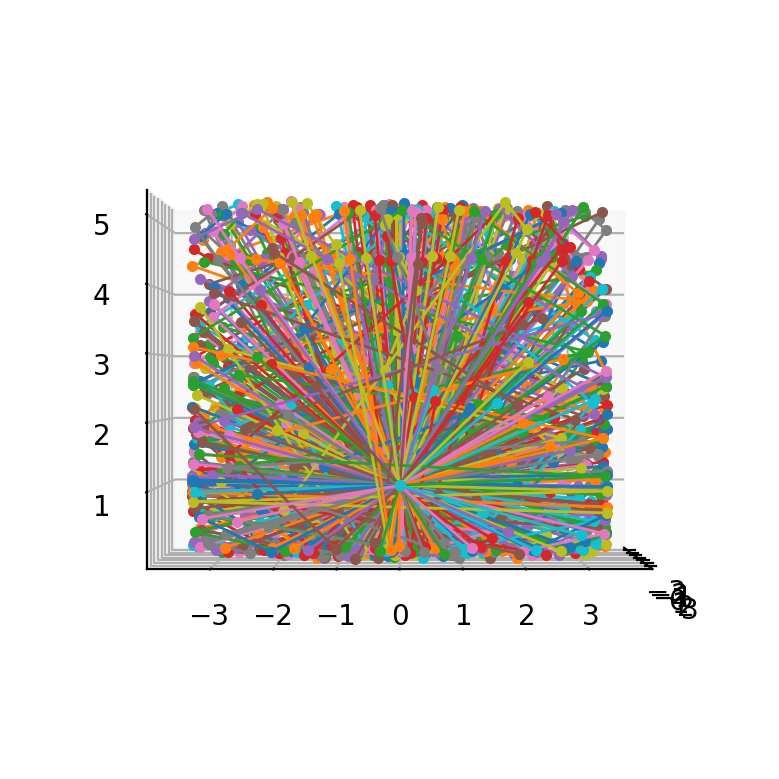

In [12]:
energyAtDeath, sensorIdsAll, total_time, step_count, paths = H.GetSingletSignal(HeRALD_v1, int(1e3),
                                                                                0, 0, 1.0,
                                                                                useMap = False,
                                                                                plot_3d = True,
                                                                                debug = True)


energyAtDeath, sensorIdsAll, total_time,\
step_count, paths = H.GetSingletSignal(HeRALD_v1,1000000,
                                       0, 0, 1.0,
                                       useMap=False,
                                       plot_3d = False,
                                       debug = True
                                       )


## Debug Analysis

When we specify the debug flag, we get a lot of information that we normally wouldn't be privy to in a real detector (e.g. original quasiparticle momentum, paths, etc.). Let's take advantage of this and make some interesting plots. There are plenty of interesting things to plot, so play around, but here are a few examples:

- Scatter plot of hit positions w/ Time delay as color axis
    - Photons take a straight line path, so of course the further the detector is from the point of interaction, the later the photon arrives. This is really just a pretty-looking sanity check; the time differentials are ~ 10 ps, to which we're not sensitive.
    - Also note the "ring-like" behavior which suggests some quantization. This is an artifact of the discrete step size used by HeST.


Text(0, 0.5, 'Y Position (cm)')

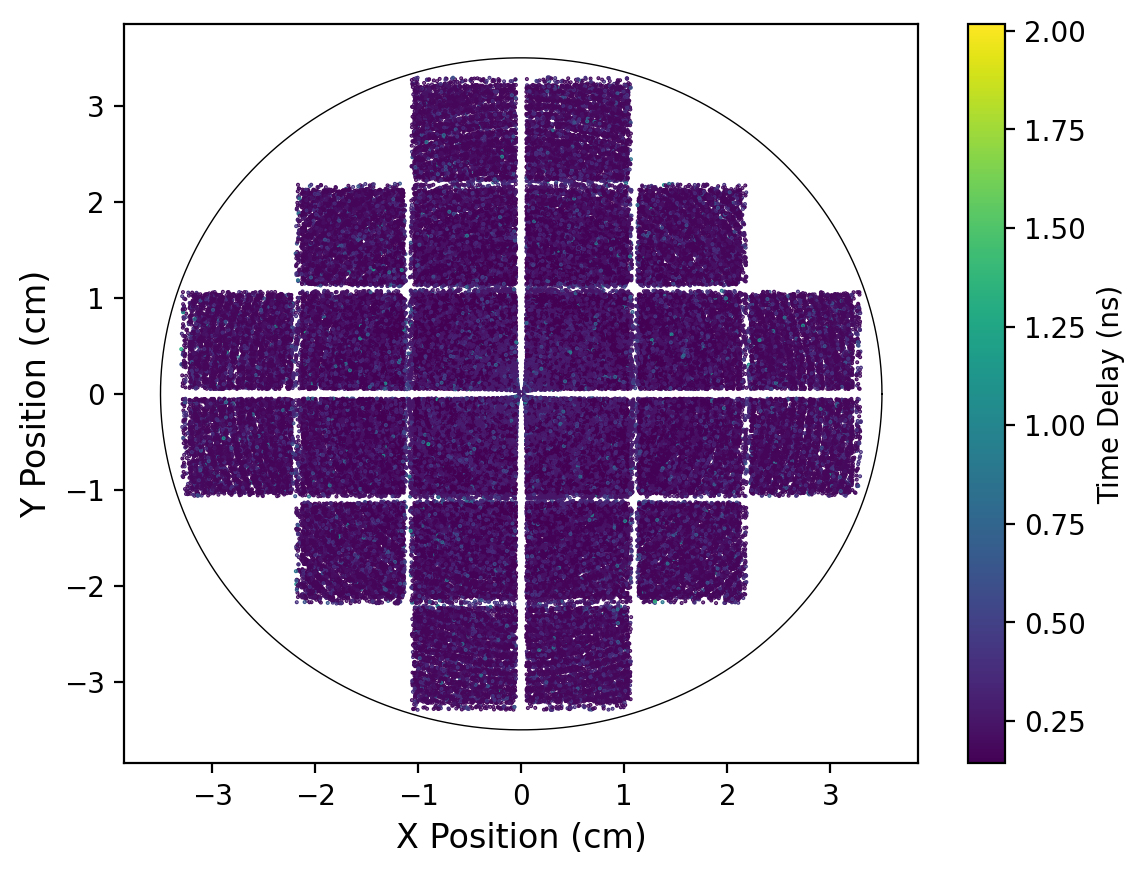

In [13]:
#sensorIdsAll contains information on undetected particles too; let's make a mask to weed out the undetected ones.
detected = sensorIdsAll > -.5

xs = paths[0]
ys = paths[1]
zs = paths[2]
xs.shape
xlist = []
ylist = []
momenta= []
times = []
channels = []
energies = []

# print(len(np.where(detected)[0]))
for i in np.where(detected)[0]:
    xlist.append(xs[i,step_count[i]])
    ylist.append(ys[i,step_count[i]])
    times.append(total_time[i]*1e3)
    channels.append(sensorIdsAll[i])
    energies.append(energyAtDeath[i]) 
xlist = np.array(xlist)
ylist = np.array(ylist)
times = np.array(times)
channels = np.array(channels)
energies = np.array(energies)




tdata = 2*np.pi*np.linspace(0,1, 1000)

fig, ax = plt.subplots()

sc = ax.scatter(xlist, ylist, s = .2, c = times, cmap='viridis')
cbar = fig.colorbar(sc, ax=ax, label = 'Time Delay (ns)')
ax.plot(3.5*np.cos(tdata), 3.5*np.sin(tdata), linewidth = .5, color = 'k')

ax.set_xlabel('X Position (cm)', fontsize = 12)
ax.set_ylabel('Y Position (cm)', fontsize = 12)


## Non-debug Simulations

We're gonna rerun our simulation with a couple of changes:
1. We're going to remove the debug flag and only take in information that we'd get out of a sensor (energy and timing)
2. We're going to run two simulations; one with reflection disabled and the other with the (diffuse) probability at ~30% (a number I pullsed out of nowhere). 
3. We're going to originate our photons off of the central axis.

It's clear that just 30% diffuse reflection makes a pretty significant difference in signal size.

Total Detection Probablitity for no reflection: 0.103612
Total Detection Probablitity for .30 reflection: 0.173573


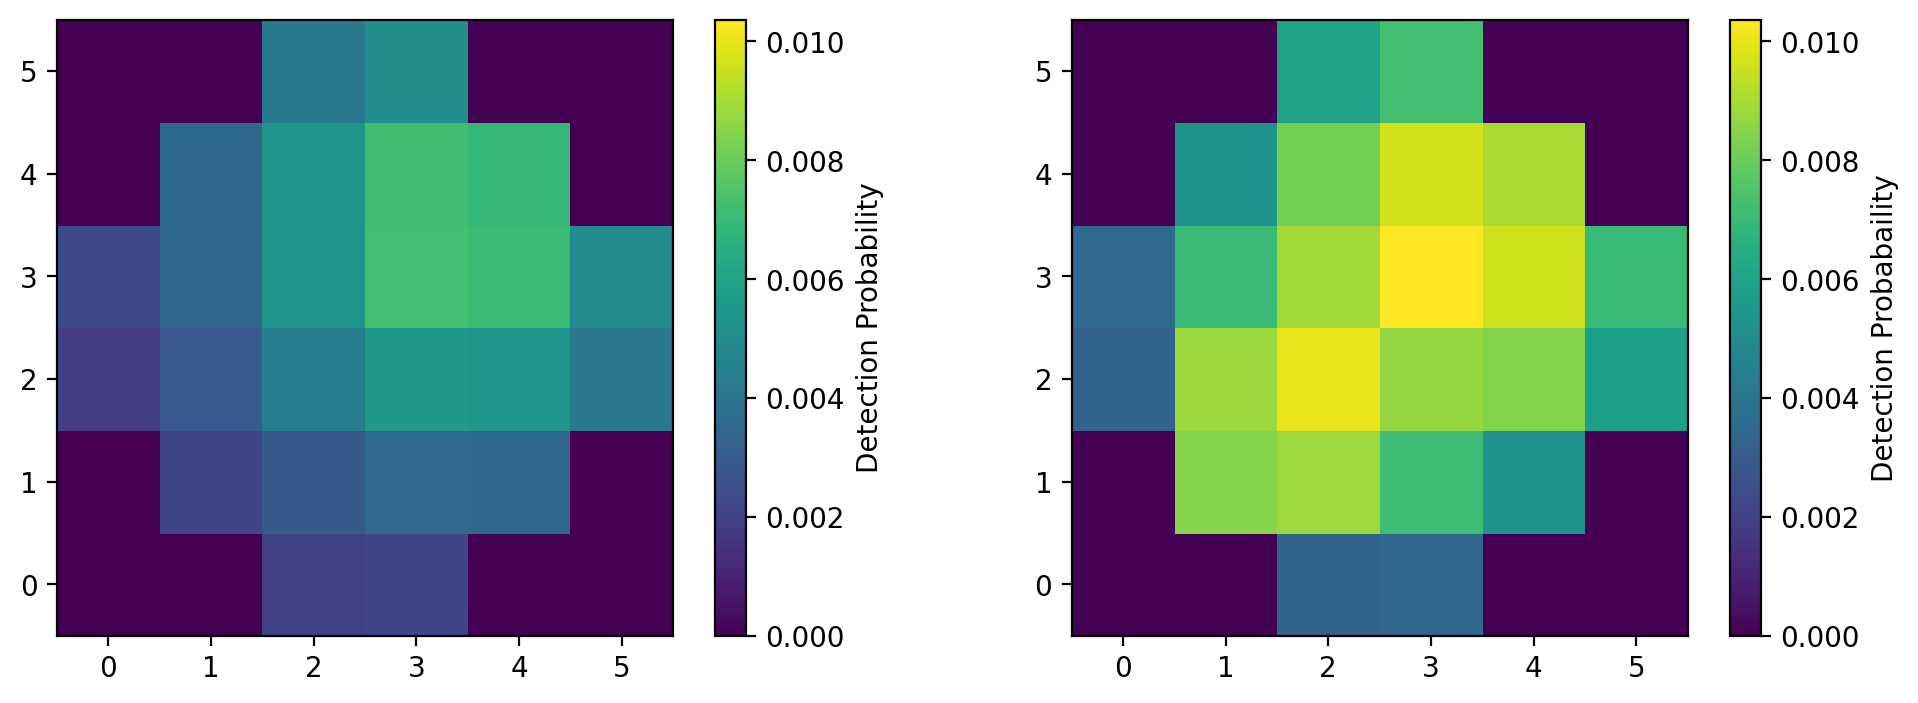

In [14]:
HeRALD_v1.set_UV_wall_reflection_prob(0.0)
Signal =  H.GetSingletSignal(HeRALD_v1, 1000000, 1.0, 1.0, 2, 
                             useMap = False,
                             plot_3d = False, 
                             debug = False)

HeRALD_v1.set_UV_wall_reflection_prob(0.3)
Signal2 =  H.GetSingletSignal(HeRALD_v1, 1000000, 1.0, 1.0, 2, 
                              useMap = False,
                              plot_3d = False, 
                              debug = False)

array = np.zeros((6,6))
array2 = np.zeros((6,6))


array_map = np.array([[0,0,1,1,0,0],
                      [0,1,1,1,1,0],
                      [1,1,1,1,1,1],
                      [1,1,1,1,1,1],
                      [0,1,1,1,1,0],
                      [0,0,1,1,0,0]])

sensor_locations = {}
sensor_id = 0
sqcm_pitch = 1.1
for i in range(array_map.shape[0]):
        for j in range(array_map.shape[1]):
            if array_map[i,j] > .5:
                x0, y0 = (i - 2.5)*sqcm_pitch, (j - 2.5)*sqcm_pitch, 
                # print(x0,y0)
                sensor_locations[str(sensor_id)] = (x0,y0)
                sensor_id += 1


for key in sensor_locations:
    x0,y0 = sensor_locations[key]
    x0 /= 1.1
    y0 /= 1.1
    x0 += 2.5
    y0 += 2.5
    array[int(y0), int(x0)] = np.sum(Signal.energies[int(key)])
    array2[int(y0), int(x0)] = np.sum(Signal2.energies[int(key)])



array /= (1000000*16)
array2 /= (1000000*16)
max = np.max([np.max(array), np.max(array2)])

fig, ax = plt.subplots(ncols = 2, figsize = (12,4))

im = ax[0].imshow(array, origin='lower', vmin = 0, vmax = max)
im2 = ax[1].imshow(array2, origin='lower', vmin = 0, vmax = max)

print('Total Detection Probablitity for no reflection: '+str(np.sum(array)))
print('Total Detection Probablitity for .30 reflection: '+str(np.sum(array2)))

fig.colorbar(im, label = 'Detection Probability')
fig.colorbar(im2, label = 'Detection Probabaility')

